<a href="https://colab.research.google.com/github/Aasim72/Data-Science-ML-Projects/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Context
This case requires trainees to develop a model for predicting fraudulent transactions for a
financial company and use insights from the model to develop an actionable plan. Data for the
case is available in CSV format having 6362620 rows and 10 columns.
Candidates can use whatever method they wish to develop their machine learning model.
Following usual model development procedures, the model would be estimated on the
calibration data and tested on the validation data. This case requires both statistical analysis and
creativity/judgment. We recommend you spend time on both fine-tuning and interpreting the
results of your machine learning model.

# Candidate Expectations
Your task is to execute the process for proactive detection of fraud while answering following
questions.
1. Data cleaning including missing values, outliers and multi-collinearity.
2. Describe your fraud detection model in elaboration.
3. How did you select variables to be included in the model?
4. Demonstrate the performance of the model by using best set of tools.
5. What are the key factors that predict fraudulent customer?
6. Do these factors make sense? If yes, How? If not, How not?
7. What kind of prevention should be adopted while company update its infrastructure?
8. Assuming these actions have been implemented, how would you determine if they work?

In [ ]:
# Importing required Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import VarianceThreshold
from scipy import stats

In [ ]:
# Uploading Data Set as a local file

from google.colab import files
data = files.upload()

Saving Fraud.csv to Fraud.csv


In [ ]:
ls

Fraud.csv  sample_data/


In [ ]:
# Creating a dataframe from dataset
# Load the Dataset

df = pd.read_csv('Fraud.csv')

In [ ]:
# Data Exploration
# Check initial records

print("First few rows of the dataset:")
print(df.head())

First few rows of the dataset:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [ ]:
# Information of the dataframe

print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None


In [ ]:
# Display the number of rows and columns

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 6362620
Number of columns: 11


In [ ]:
# Check for missing values

missing_values = df.isnull().sum()
print("Missing values per column")
print(missing_values)

Missing values per column
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [ ]:
# Data Cleaning
# Fill missing values or drop them
# df.fillna(df.mean(), inplace=True)  # Filling with mean for numerical columns
# You can skip this step as there is no Null values in the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


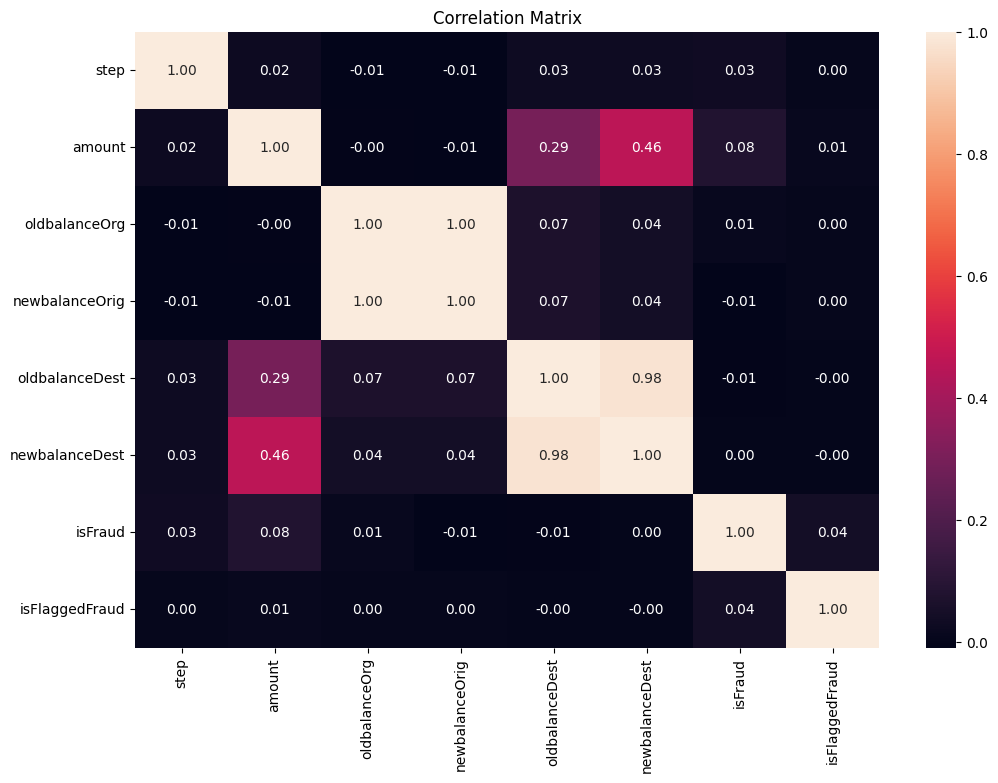

                    step    amount  oldbalanceOrg  newbalanceOrig  \
step            1.000000  0.022373      -0.010058       -0.010299   
amount          0.022373  1.000000      -0.002762       -0.007861   
oldbalanceOrg  -0.010058 -0.002762       1.000000        0.998803   
newbalanceOrig -0.010299 -0.007861       0.998803        1.000000   
oldbalanceDest  0.027665  0.294137       0.066243        0.067812   
newbalanceDest  0.025888  0.459304       0.042029        0.041837   
isFraud         0.031578  0.076688       0.010154       -0.008148   
isFlaggedFraud  0.003277  0.012295       0.003835        0.003776   

                oldbalanceDest  newbalanceDest   isFraud  isFlaggedFraud  
step                  0.027665        0.025888  0.031578        0.003277  
amount                0.294137        0.459304  0.076688        0.012295  
oldbalanceOrg         0.066243        0.042029  0.010154        0.003835  
newbalanceOrig        0.067812        0.041837 -0.008148        0.003776  
old

In [ ]:
# Check for multi-collinearity
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()
print(correlation_matrix)

In [ ]:
# Convert categorical columns to dummy/indicator variables
# you can also use pd.get_dummies option also but I prefer LabelEncoder

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [ ]:
# Define Features and Target Variable
X = df.drop(['isFraud', 'nameOrig', 'nameDest'], axis=1)  # Exclude target and non-numeric columns
y = df['isFraud']

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,3,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,4,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,3,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
X.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,0
3,1,1,181.00,181.0,0.00,21182.0,0.0,0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0


In [ ]:
y.head()

,isFraud
0,0
1,0
2,1
3,1
4,0


In [ ]:
# Split the Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standardize the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make Predictions
y_pred = rf_model.predict(X_test)

# Evaluate the Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nAccuraccy Score:")
print(accuracy_score(y_test, y_pred))

Confusion Matrix:
[[1270881      23]
 [    324    1296]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.98      0.80      0.88      1620

    accuracy                           1.00   1272524
   macro avg       0.99      0.90      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524


Accuraccy Score:
0.9997273135909421


In [ ]:
# Train Decision Tree Classifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Make Predictions
y_pred = dt_model.predict(X_test)

# Evaluate the Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nAccuraccy Score:")
print(accuracy_score(y_test, y_pred))

Confusion Matrix:
[[1270752     152]
 [    199    1421]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.90      0.88      0.89      1620

    accuracy                           1.00   1272524
   macro avg       0.95      0.94      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524


Accuraccy Score:
0.9997241702317599


In [ ]:
# Train SVM Classifier

svc_model = SVC()
svc_model.fit(X_train, y_train)

# Make Predictions
y_pred = svc_model.predict(X_test)

# Evaluate the Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nAccuraccy Score:")
print(accuracy_score(y_test, y_pred))

Confusion Matrix:
[[1270901       3]
 [    901     719]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       1.00      0.44      0.61      1620

    accuracy                           1.00   1272524
   macro avg       1.00      0.72      0.81   1272524
weighted avg       1.00      1.00      1.00   1272524


Accuraccy Score:
0.9992896008248174


In [ ]:
# Train Logistic Regression Classifier

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Make Predictions
y_pred = lr_model.predict(X_test)

# Evaluate the Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nAccuraccy Score:")
print(accuracy_score(y_test, y_pred))

Confusion Matrix:
[[1270803     101]
 [    936     684]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.87      0.42      0.57      1620

    accuracy                           1.00   1272524
   macro avg       0.94      0.71      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524


Accuraccy Score:
0.9991850841320085


In [ ]:
# Train K Nearest Neighbor Classifier

#knn_model = KNeighborsClassifier()
#


k_values = range(1, 40)
scores = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    knn_model.predict(X_test)
    cv_scores = cross_val_score(knn_model, X_train, y_train, cv=5, scoring='accuracy')
    scores.append(cv_scores.mean())

# Plot accuracy vs k
plt.plot(k_values, scores, color='blue',marker='o',linestyle='--',markerfacecolor='red',
        markersize=10)
plt.xlabel("Value of K")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Choosing Optimal K for KNN")
plt.show()

best_k = k_values[scores.index(max(scores))]
print("Best K:", best_k)

print(f'With K = {best_k}\n')
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train,y_train)

# Make Predictions
y_pred = knn_model.predict(X_test)

# Evaluate the Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nAccuraccy Score:")
print(accuracy_score(y_test, y_pred))

NameError: name 'KNeighborsClassifier' is not defined

# Done ........